In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np

In [2]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
df = pd.read_json(url)

#📌 Extracão

In [3]:
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


#🔧 Transformação

In [4]:
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

In [5]:
df = pd.concat([df.drop(['customer'], axis=1), df_customer], axis=1)
df = pd.concat([df.drop(['phone'], axis=1), df_phone], axis=1)
df = pd.concat([df.drop(['internet'], axis=1), df_internet], axis=1)
df = pd.concat([df.drop(['account'], axis=1),df_account], axis=1)

In [6]:
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [7]:
df.iloc[0]

customerID            0002-ORFBO
Churn                         No
gender                    Female
SeniorCitizen                  0
Partner                      Yes
Dependents                   Yes
tenure                         9
PhoneService                 Yes
MultipleLines                 No
InternetService              DSL
OnlineSecurity                No
OnlineBackup                 Yes
DeviceProtection              No
TechSupport                  Yes
StreamingTV                  Yes
StreamingMovies               No
Contract                One year
PaperlessBilling             Yes
PaymentMethod       Mailed check
Charges.Monthly             65.6
Charges.Total              593.3
Name: 0, dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


Transformando colunas que eram do tipo object para o tipo float ou int

In [9]:
df['tenure'] = df['tenure'].astype(int)

In [10]:
x = df['Charges.Total'].astype(str).str.strip().replace('', np.nan)
df['Charges.Total'] = pd.to_numeric(x, errors='coerce').astype(np.float64)

Criando a coluna Contas_Diarias

In [11]:
df['Contas_Diarias'] = df['Charges.Monthly'] / 30

Verificando valores faltantes

In [12]:
print(df.isna().sum())

customerID           0
Churn                0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Charges.Monthly      0
Charges.Total       11
Contas_Diarias       0
dtype: int64


In [13]:
df = df.dropna()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7256 non-null   object 
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   object 
 5   Dependents        7256 non-null   object 
 6   tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   object 
 8   MultipleLines     7256 non-null   object 
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   object 
 11  OnlineBackup      7256 non-null   object 
 12  DeviceProtection  7256 non-null   object 
 13  TechSupport       7256 non-null   object 
 14  StreamingTV       7256 non-null   object 
 15  StreamingMovies   7256 non-null   object 
 16  Contract          7256 non-null   object 
 17  

Optei por deletar os registros que tinham valores nulos na coluna Charges.Total pois eram poucos registros e não fazem falta para nossa análise

In [15]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


Optei por não renomear as colunas do df


#📊 Carga e análise

Iniciei com o cálculo de média, desvio padrão, quartis, mínimos e máximos das colunas de preço e de tempo de contrato

In [16]:
colunas_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Contas_Diarias']

In [17]:
for coluna in colunas_numericas:
    print(df[coluna].describe())

count    7256.000000
mean       32.395535
std        24.558067
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64
count    7256.000000
mean       64.755423
std        30.125739
min        18.250000
25%        35.450000
50%        70.300000
75%        89.900000
max       118.750000
Name: Charges.Monthly, dtype: float64
count    7256.000000
mean     2280.634213
std      2268.632997
min        18.800000
25%       400.225000
50%      1391.000000
75%      3785.300000
max      8684.800000
Name: Charges.Total, dtype: float64
count    7256.000000
mean        2.158514
std         1.004191
min         0.608333
25%         1.181667
50%         2.343333
75%         2.996667
max         3.958333
Name: Contas_Diarias, dtype: float64


Verificando os valores existentes de Churn

In [18]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
        224
Name: count, dtype: int64

Tratando valores faltantes

In [19]:
df = df.replace(r'^\s*$', np.nan, regex=True)
df.dropna(inplace=True)

In [20]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

### Plotando o gráfico que mostra a distribuição da evasão dos clientes

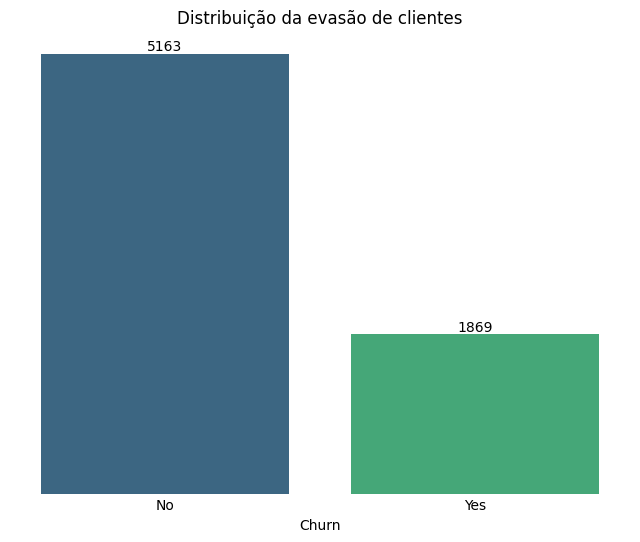

In [21]:
fig, ax = plt.subplots(figsize = (8,6))
sns.countplot(x = df['Churn'], palette='viridis', hue = df['Churn'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribuição da evasão de clientes')
ax.tick_params(axis = 'both', length = 0)
ax.set_yticks([])
ax.set_ylabel('')
plt.box(False)
plt.show()

### Analisando a distribuição da evasão de acordo com variáveis categóricas

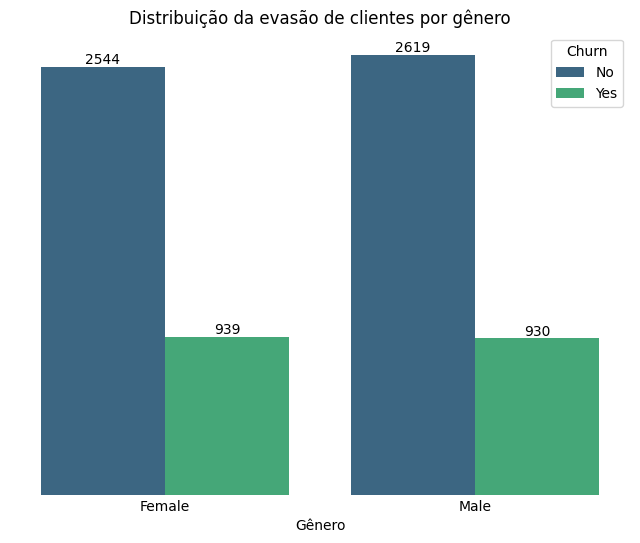

In [22]:
fig, ax = plt.subplots(figsize = (8,6))
sns.countplot(data = df, x = 'gender', hue = 'Churn', palette='viridis')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribuição da evasão de clientes por gênero')
ax.tick_params(axis = 'both', length = 0)
ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('Gênero')
plt.box(False)
plt.show()

O gênero do contratante não é um fator importante nesta análise


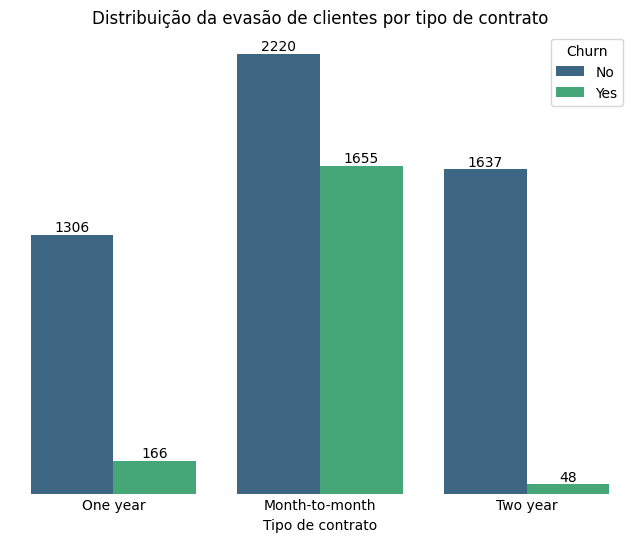

In [23]:
fig, ax = plt.subplots(figsize = (8,6))
sns.countplot(data = df, x = 'Contract', hue = 'Churn', palette='viridis')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribuição da evasão de clientes por tipo de contrato')
ax.tick_params(axis = 'both', length = 0)
ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('Tipo de contrato')
plt.box(False)
plt.show()

A partir desse gráfico que mostra a evasão por tipo de contrato, podemos perceber que clientes com contratos mensais costumam ter uma evasão maior, o que mostra a importância de ao realizar novos contratos, tentar fazer contratos anuais ou de dois anos.

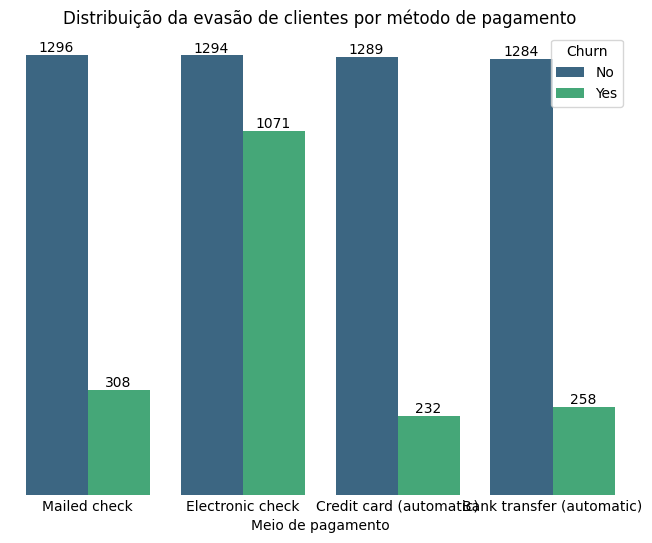

In [24]:
fig, ax = plt.subplots(figsize = (8,6))
sns.countplot(data = df, x = 'PaymentMethod', hue = 'Churn', palette='viridis')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribuição da evasão de clientes por método de pagamento')
ax.tick_params(axis = 'both', length = 0)
ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('Meio de pagamento')
plt.box(False)
plt.show()

Ao analisar o gráfico de evasão de clientes por meio de pagamento, podemos observar que a maioria dos clientes que fazem o cancelamento são os que pagam por meio de 'eletronic check' ou cheque eletrônico, isso pode ser um indicativo da dificuldade de realizar os pagamentos por esse meio, o que gera um incômodo ao cliente, com isso, o setor comercial pode tentar retirar esse meio de pagamento ou, no período de compra, indicar outro meio de pagamento.

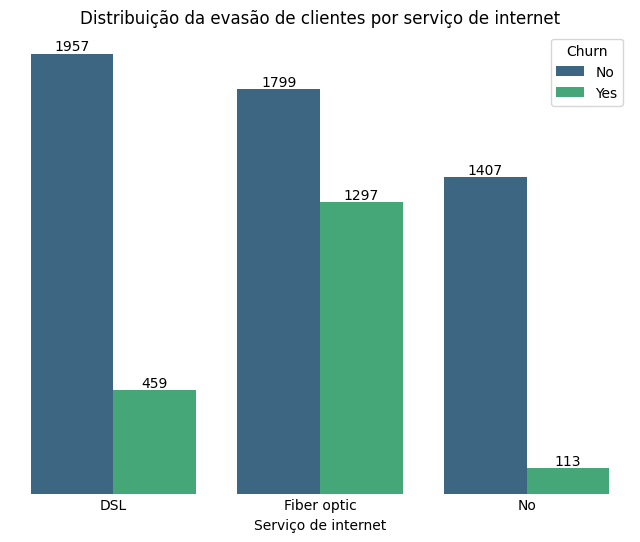

In [25]:
fig, ax = plt.subplots(figsize = (8,6))
sns.countplot(data = df, x = 'InternetService', hue = 'Churn', palette='viridis')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribuição da evasão de clientes por serviço de internet')
ax.tick_params(axis = 'both', length = 0)
ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('Serviço de internet')
plt.box(False)
plt.show()

Ao observar o gráfico de evasão de clientes por serviço de internet, podemos observar que a maioria dos clientes que cancelam os serviços são os que tinha o serviço de fibra optica, isso pode indicar um mal funcionamento deste serviço, como lentidão e instabilidades, o que deve ser reportado ao setor de suporte técnico, para saber se esse mal funcionamento de fato se concretiza.


In [26]:
lista_cols = [ 'SeniorCitizen', 'Partner',
       'Dependents', 'PhoneService', 'MultipleLines',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling']

In [27]:
def grafico(coluna): 
    fig, ax = plt.subplots(figsize = (8,6))
    sns.countplot(data = df, x = coluna, hue = 'Churn', palette='viridis')
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(f'Distribuição da evasão de clientes por {coluna}')
    ax.tick_params(axis = 'both', length = 0)
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_xlabel(f'{coluna}')
    plt.box(False)
    plt.show()

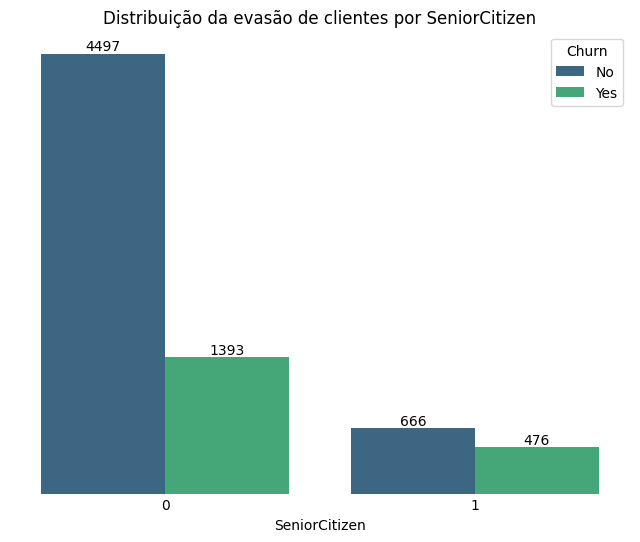

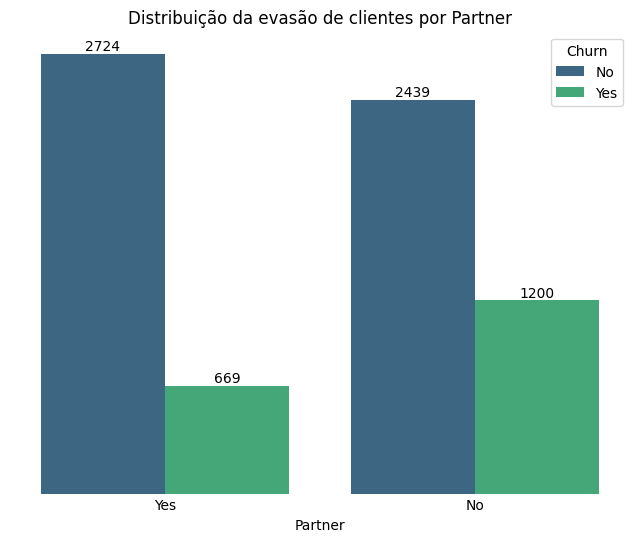

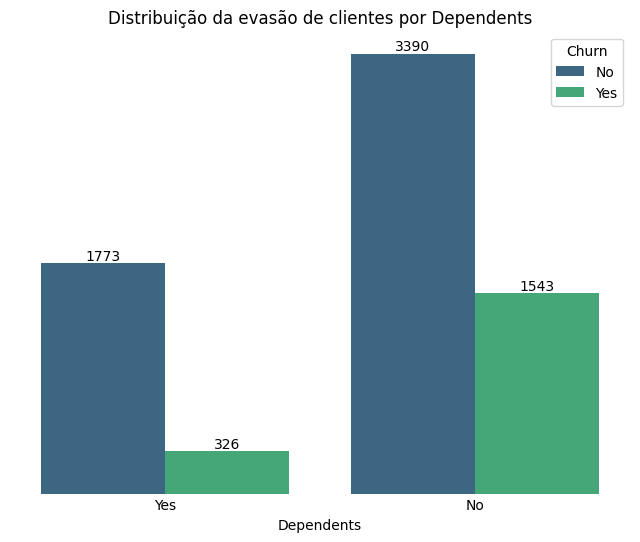

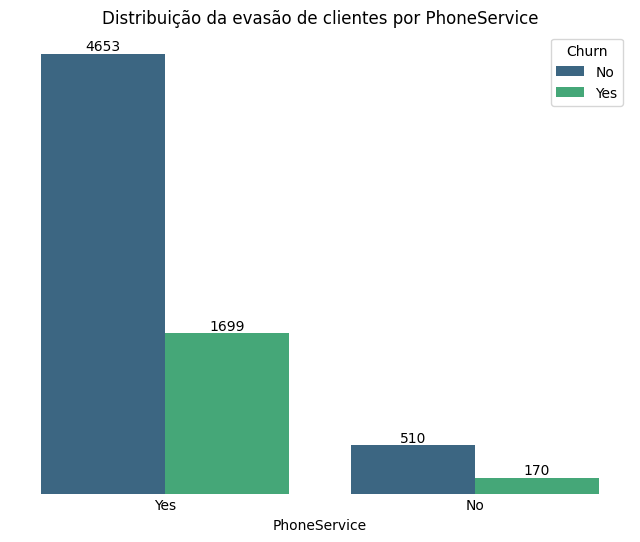

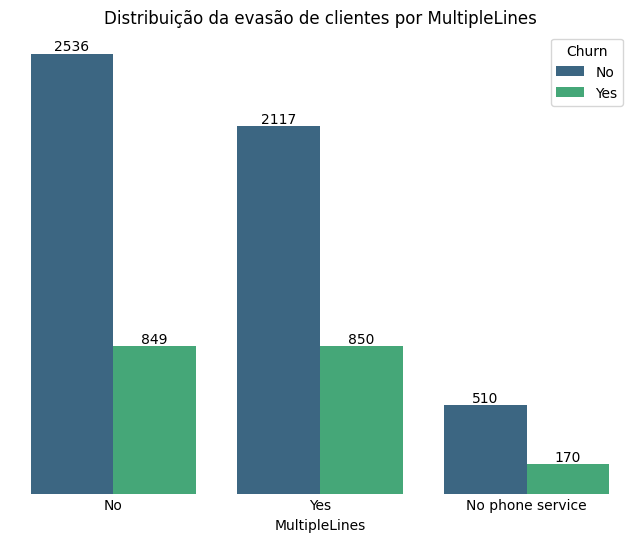

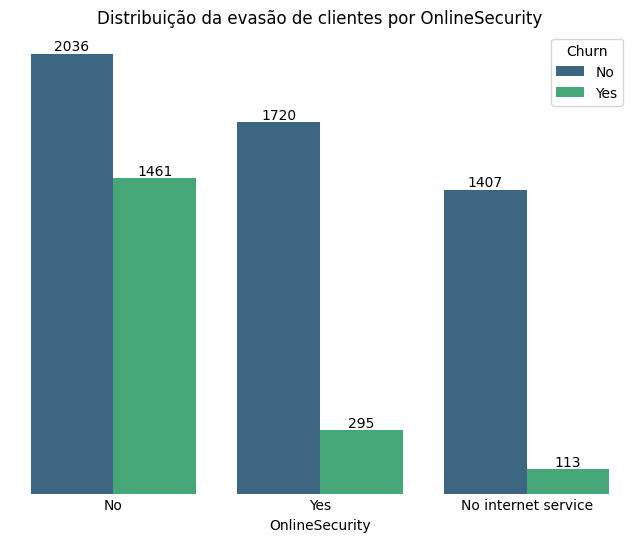

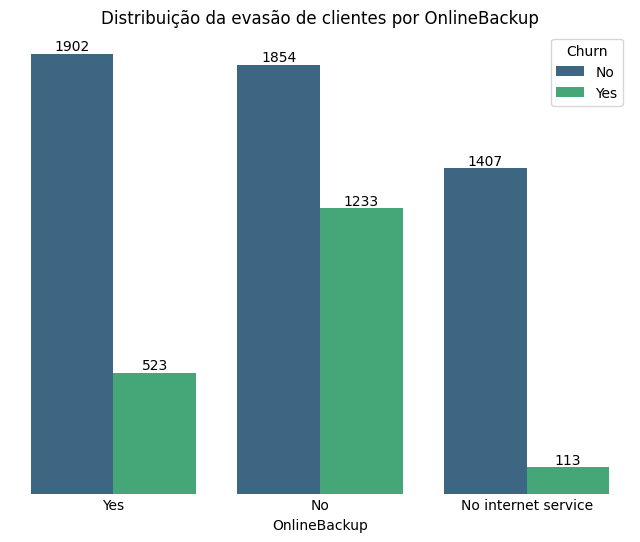

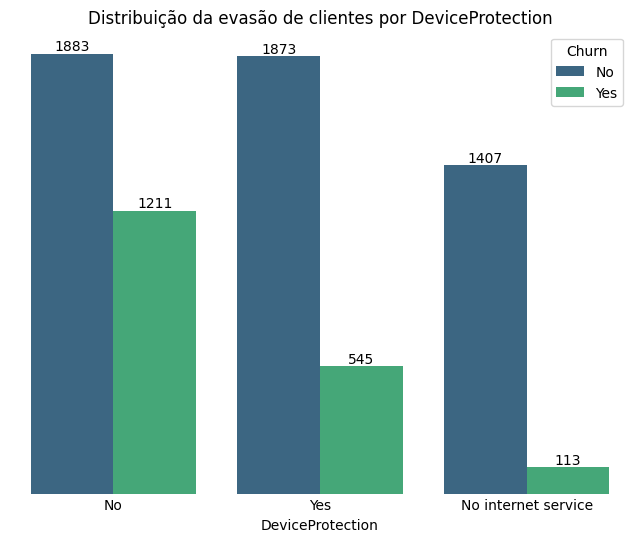

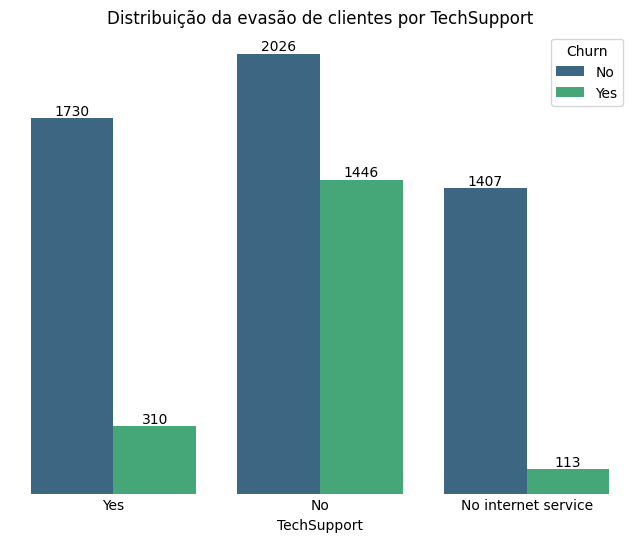

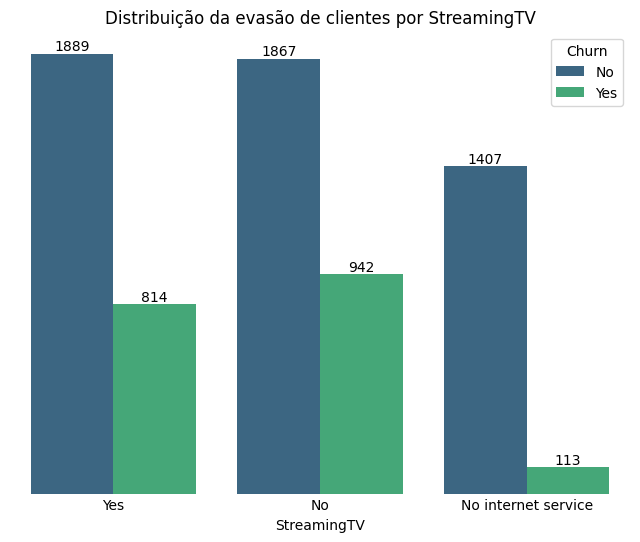

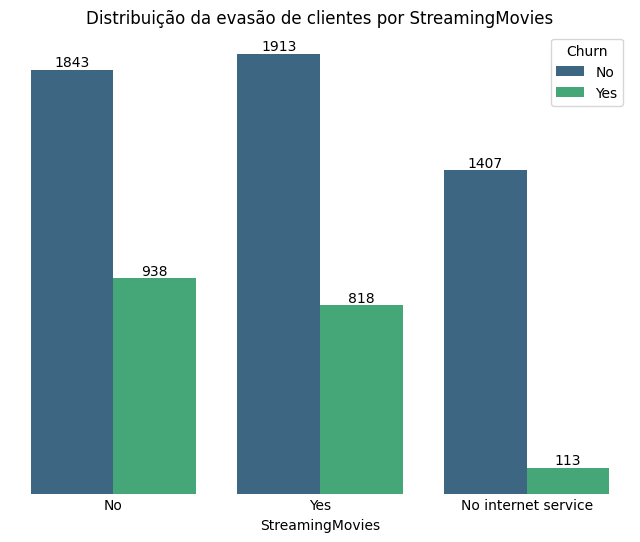

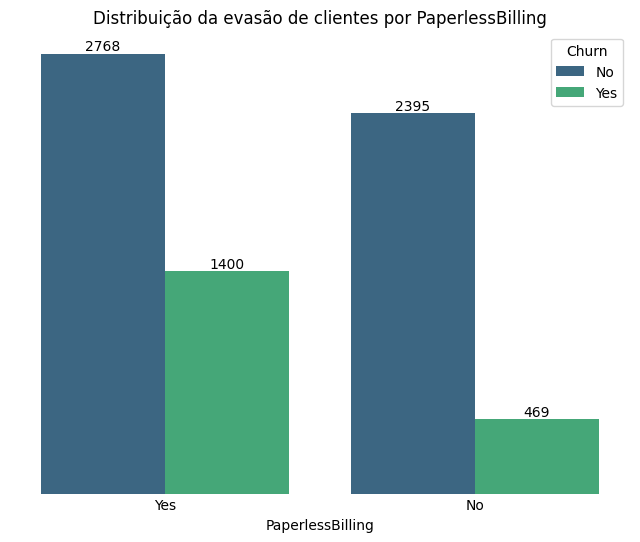

In [28]:
for coluna in lista_cols:
    grafico(coluna)


### Analisando variáveis numéricas

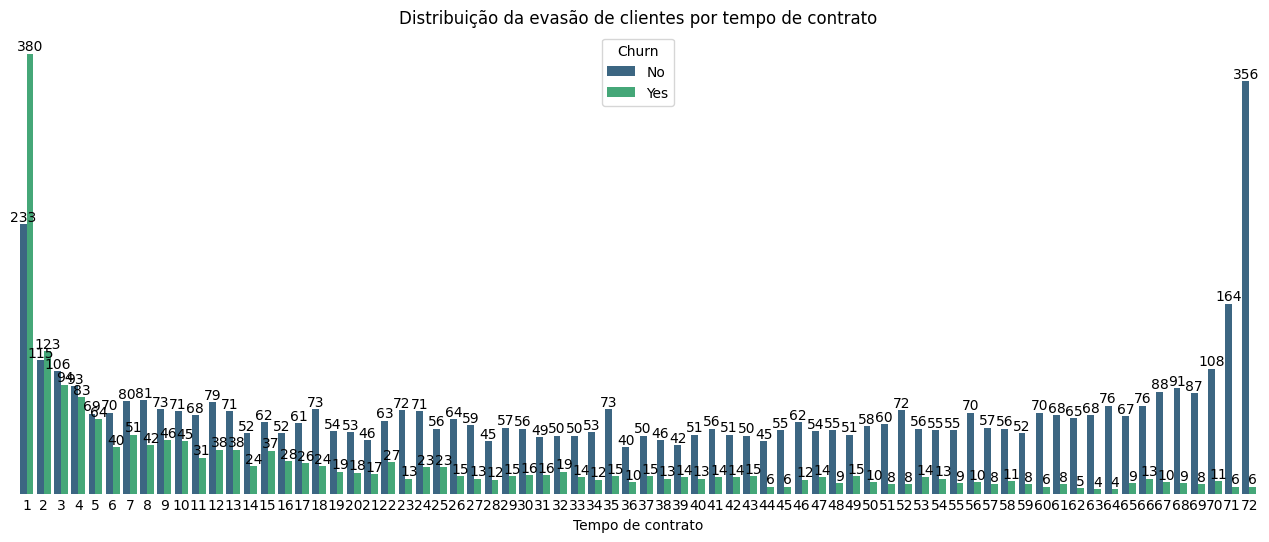

In [29]:
fig, ax = plt.subplots(figsize = (16,6))
sns.countplot(data = df, x = 'tenure', hue = 'Churn', palette='viridis')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribuição da evasão de clientes por tempo de contrato')
ax.tick_params(axis = 'both', length = 0)
ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('Tempo de contrato')
plt.box(False)
plt.show()

Por mais que o gráfico pareça bagunçado, podemos perceber que os valores que distoam são os menores, logo, os clientes que mais cancelam são os com 1 ou 2 meses de contrato, para evitar isso, podemos oferecer descontos nos meses iniciais e descontos ao fazer planos anuais ou bi-anuais, para segurar esse cliente na empresa e evitar cancelamentos precoces.

A partir do terceiro mês de contrato, o churn tende a diminuir, sendo assim, podemos testar diferentes estratégias para melhorar esses indicadores nos meses iniciais.

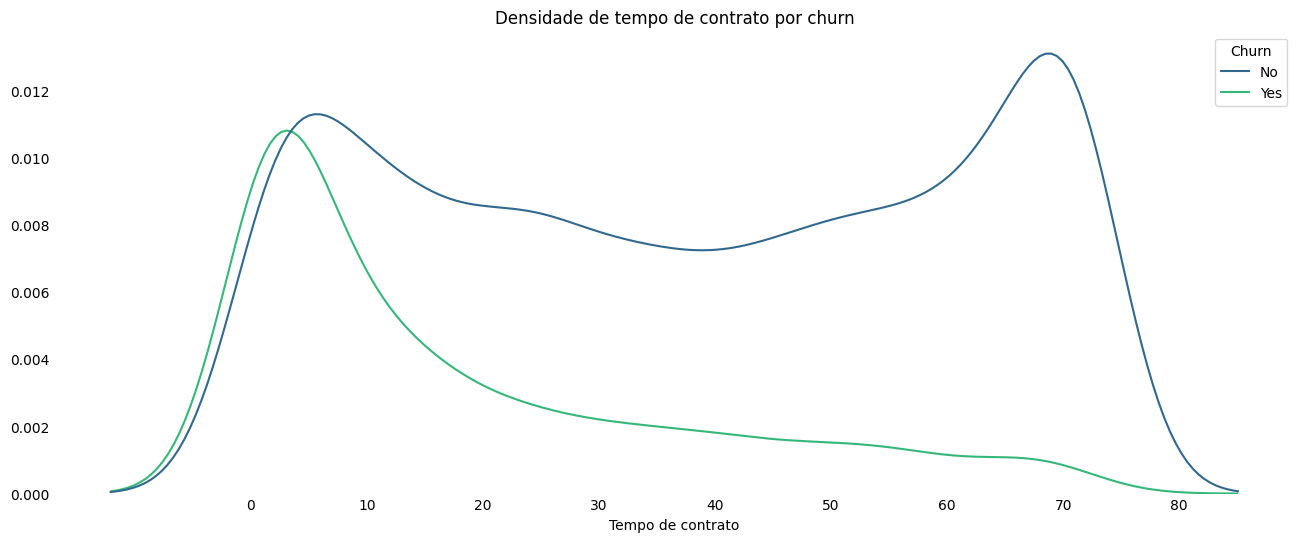

In [30]:

fig, ax = plt.subplots(figsize = (16,6))
sns.kdeplot(data = df, x = 'tenure', hue = 'Churn', palette = 'viridis')
plt.title('Densidade de tempo de contrato por churn')
ax.tick_params(axis = 'both', length = 0)
#ax.set_yticks([])
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
ax.set_ylabel('')
ax.set_xlabel('Tempo de contrato')
plt.box(False)
plt.show()

Esse gráfico mostra a desidade dos valores de churn de acordo com o tempo de contrato, por ele podemos perceber que contratos recentes tem maior possibilidade de serem cancelados, a altura da curva do churn = 'Yes' é maior no início do gráfico e vai diminuindo com o passar do tempo, enquanto a curva do churn = 'No' vai aumentando, sendo assim, podemos confirmar a análise feita anteriormente, que diz que contratos no início tem maior chance de serem cancelados.

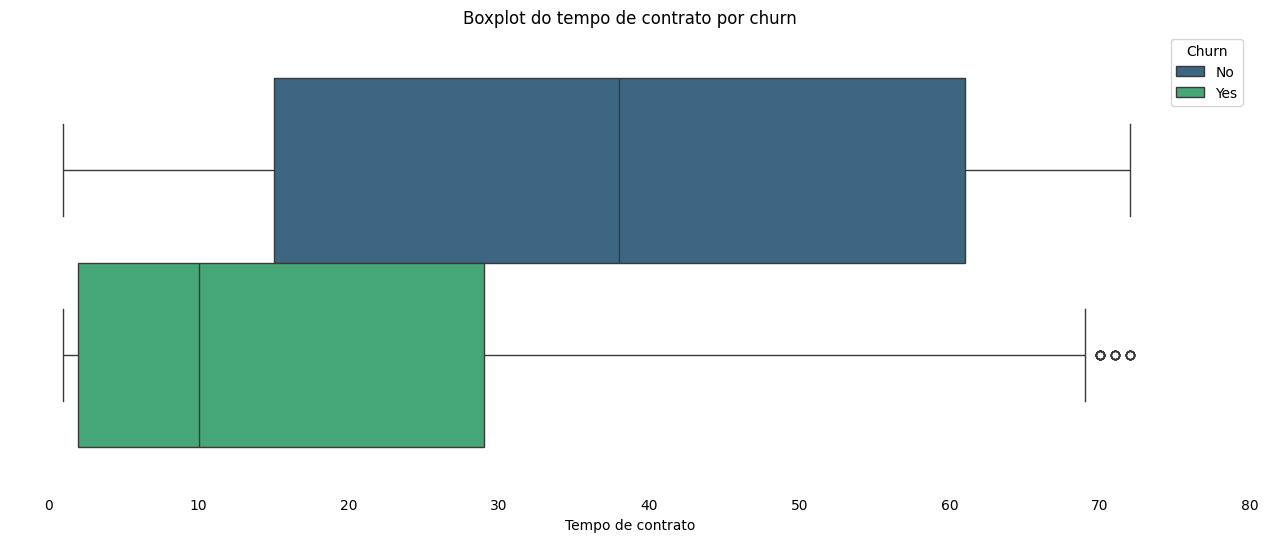

In [31]:
fig, ax = plt.subplots(figsize = (16,6))
sns.boxplot(data = df, x = 'tenure', hue = 'Churn', palette = 'viridis')
plt.title('Boxplot do tempo de contrato por churn')
ax.tick_params(axis = 'both', length = 0)
#ax.set_yticks([])
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
ax.set_ylabel('')
ax.set_xlabel('Tempo de contrato')
plt.box(False)
plt.show()

O boxplot é outro gráfico que evidencia essa afirmação, uma vez que ele mostra que 75% dos cancelamentos estão concentrados entre 0 e 30 meses, sendo que 50% está concentrado em até 10 meses.

In [32]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Contas_Diarias'],
      dtype='object')

#### Total Gasto

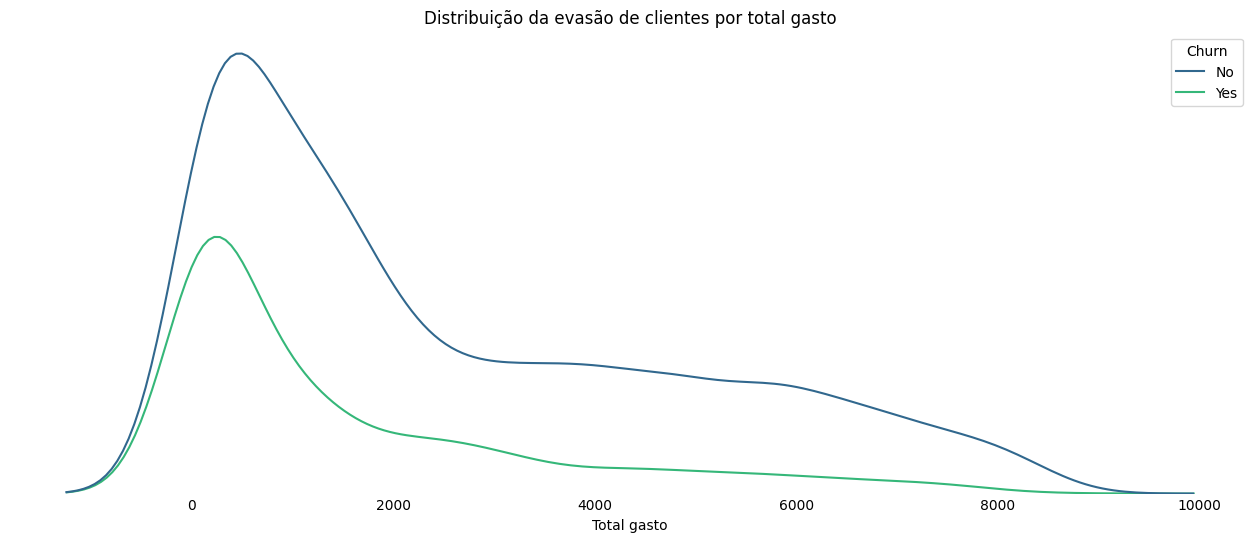

In [33]:
fig, ax = plt.subplots(figsize = (16,6))
sns.kdeplot(data = df, x = 'Charges.Total', hue = 'Churn', palette='viridis')
plt.title('Distribuição da evasão de clientes por total gasto')
ax.tick_params(axis = 'both', length = 0)
ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('Total gasto')
plt.box(False)
plt.show()

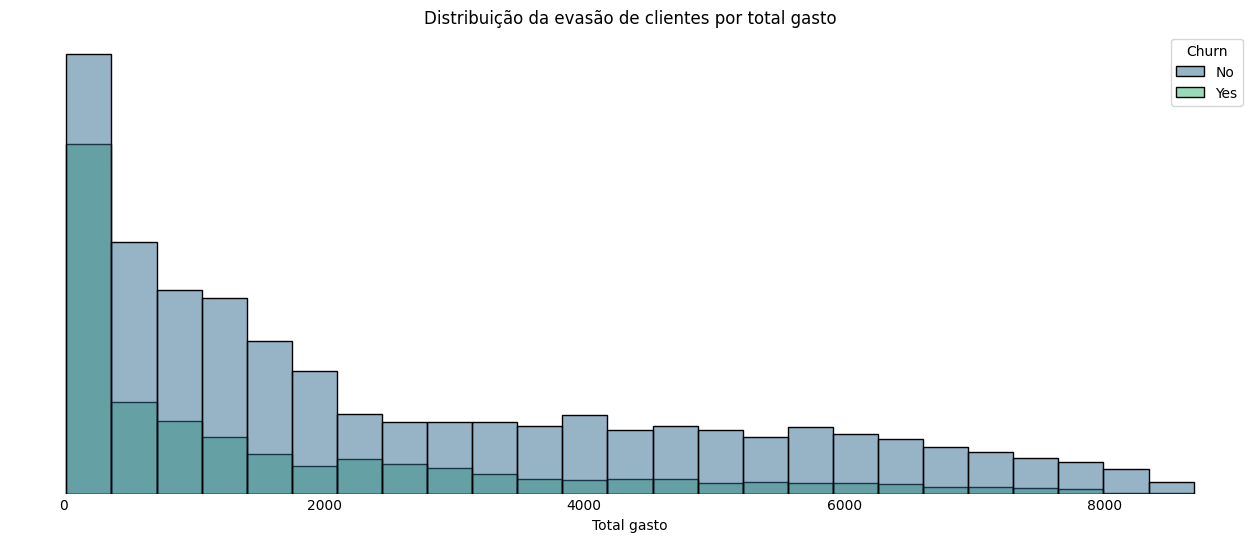

In [40]:
fig, ax = plt.subplots(figsize = (16,6))
sns.histplot(data = df, x = 'Charges.Total', hue = 'Churn', palette='viridis')
plt.title('Distribuição da evasão de clientes por total gasto')
ax.tick_params(axis = 'both', length = 0)
ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('Total gasto')
plt.box(False)
plt.show()

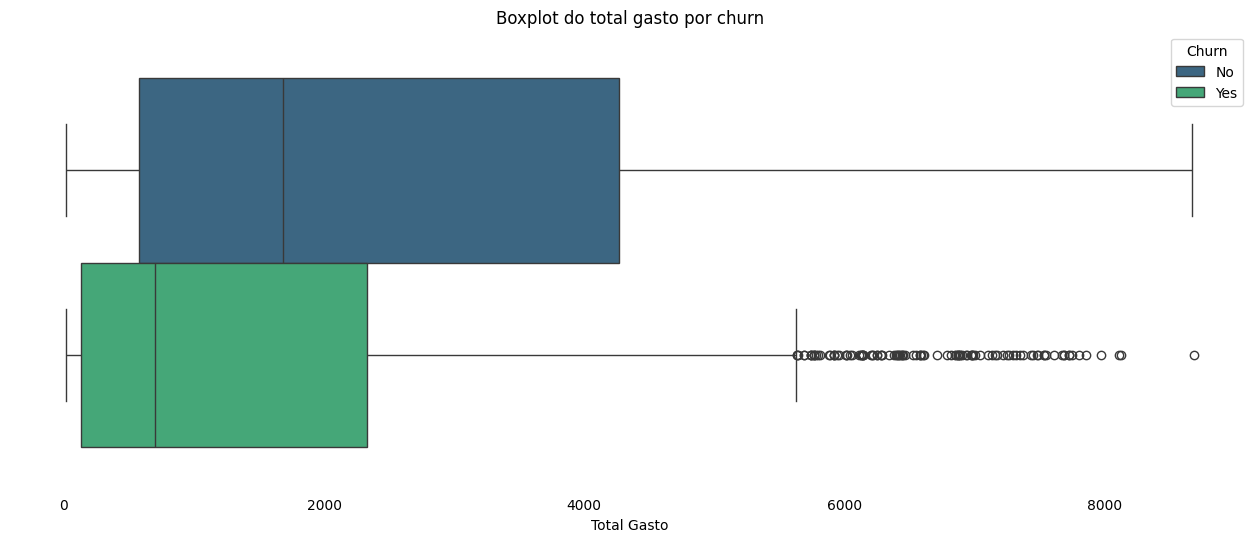

In [39]:
fig, ax = plt.subplots(figsize = (16,6))
sns.boxplot(data = df, x = 'Charges.Total', hue = 'Churn', palette = 'viridis')
plt.title('Boxplot do total gasto por churn')
ax.tick_params(axis = 'both', length = 0)
#ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('Total Gasto')
plt.box(False)
plt.show()

Esses gráficos mostram que clientes os clientes que cancelaram suas assinaturas tem um total gasto baixo, isso está altamente relacionado com o tempo de contrato, visto que, quanto menor o tempo de contrato, menor o total gasto por esse cliente, sendo assim, percebemos uma correlação entre as análises.

#📄Relatorio Final

Foi proposto o desafio de analisar a evasão de clientes da Telecom X, o objetivo da análise é basicamente entender o porque do número significativo de cancelamento dos clientes, a análise passou por diversas colunas da base de dados e foi feita uma análise crítica dos dados disponíveis, onde foram plotados gráficos para auxiliar na análise e facilitar a visualização e compreendimento dos dados, o que ajuda a trazer insights e facilita a tomada de decisões.

Iniciamos o projeto importando a base de dados, que estava no formato json. Na primeira tentativa vimos que existiam colunas importantes faltando, visto que tínhamos dicionários aninhados dentro do arquivo, o que fez com que todas as colunas não fossem exibidas, sendo assim, precisamos normalizar essas colunas para obter todas as informações corretamente. Na fase de limpeza e tratamento de dados, removemos dados nulos para facilitar na análise.

Na parte de EDA, fizemos uma análise rebuscada sobre os dados numéricos e categórios da base de dados, todos ligados ao churn, em que podemos ver como esses dados se relacionavam e identificamos alguns comportamentos que podem nos mostrar caminhos para diminuição do cancelamento de assinaturas.

Por fim, trago minhas conclusões baseadas na análise dos dados da Telecom X.

A partir desse gráfico que  mostra a desidade entre o tempo de contrato e o cancelamento de assinaturas, podemos perceber que a maioria dos cancelamentos são feitos por clientes com pouco tempo de contrato, 50% do cancelamento é feito por clientes que tem até 10 meses de contrato, isso mostra que precisamos tomar novas iniciativas que prendam o cliente no período inicial do seu contrato com a empresa, sejam essas iniciativas, descontos para contratos semestrais e desconto progressivo para contratos maiores, como anuais ou bi-anuais, descontos nos primeiros 3 meses de contrato, entre outras possíveis medidas.

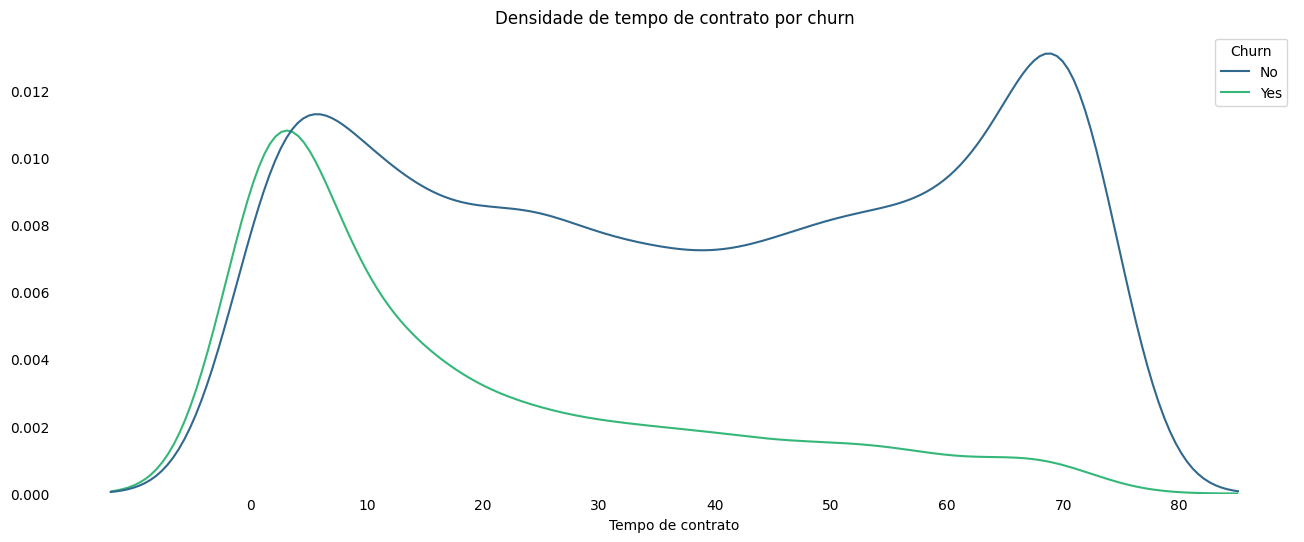

Esse gráfico mostra a relação do churn com o tipo de contrato do cliente, o que reforça o que foi falado anteriormente, de que clientes com contratos mensais tendem a cancelar o contrato com maior facilidade, por isso, temos um churn maior nos primeiros meses, logo, contratos anuais ou de dois anos, podem ser mais efetivos. 

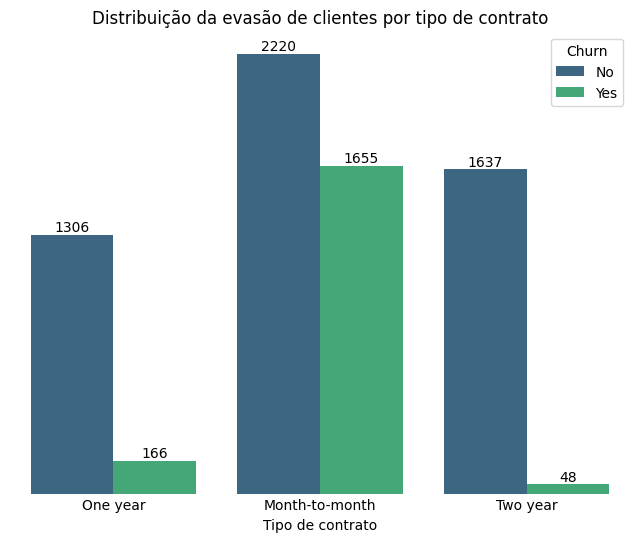

Outro fator importante que eu analisei foi a relação do churn com o tipo de serviço de internet contratado, a partir do gráfico abaixo podemos observar que clientes que contratam o serviço de internet por fibra óptica tem índices maiores de cancelamento, o que pode ser ocasionado por um mal funcionamento deste serviço ou por constantes instabilidades, então deve ser debatido com o setor responsável para entender se o serviço de fato está passando por problemas e a partir disso quais medidas podem ser tomadas para melhorá-lo e assimm, diminuir o cancelamento de clientes.

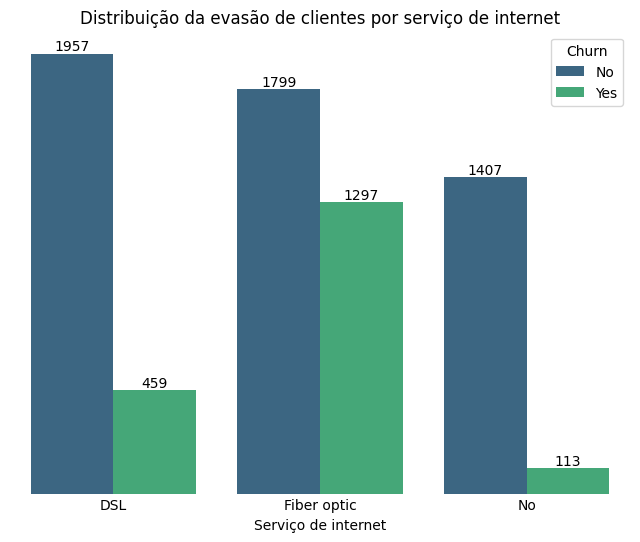

Ao analisar o gráfico de evasão de clientes por meio de pagamento, podemos observar que a maioria dos clientes que fazem o cancelamento são os que pagam por meio de 'eletronic check' ou cheque eletrônico, isso pode ser um indicativo da dificuldade de realizar os pagamentos por esse meio, o que gera um incômodo ao cliente, com isso, o setor comercial pode tentar retirar esse meio de pagamento ou, no período de compra, indicar outro meio de pagamento ao cliente afim de diminuir esse transtorno e tornar a experiência de compra mais simplificada, aumentando a adesão do cliente.

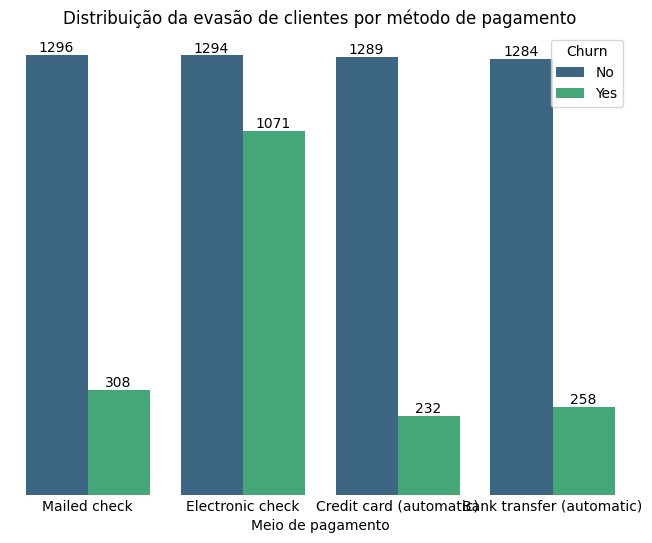
